In [ ]:
!pip install mediapipe

     |████████████████████████████████| 32.8 MB 40.0 MB/s 


In [ ]:
# import necessary packages
import os
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt

In [ ]:
bg_image = cv2.imread("path_to_image")

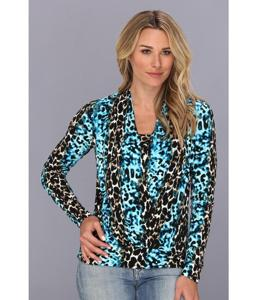

In [ ]:
from google.colab.patches import cv2_imshow

cv2_imshow(bg_image)

In [ ]:
# initialize mediapipe
mp_selfie_segmentation = mp.solutions.selfie_segmentation
selfie_segmentation = mp_selfie_segmentation.SelfieSegmentation()

In [ ]:
height , width, channel = bg_image.shape

(-0.5, 257.5, 299.5, -0.5)

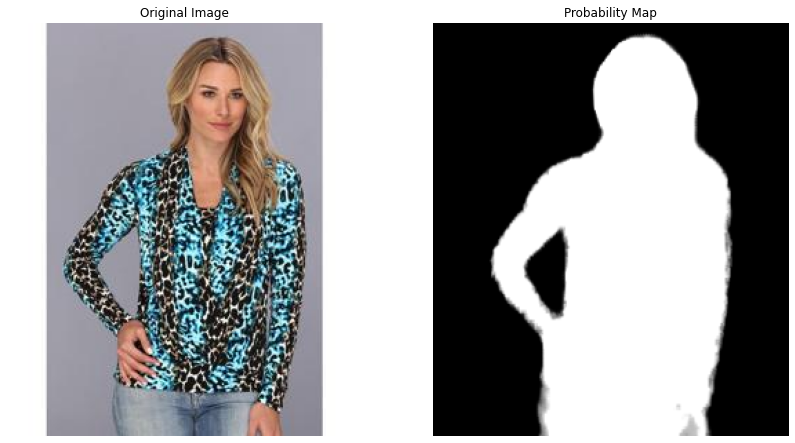

In [ ]:
bg_image_rgb = cv2.cvtColor(bg_image, cv2.COLOR_BGR2RGB)
#bg_image_rgb = cv2.cvtColor(bg_image, cv2.COLOR_BGR2RGB)

# get the result
results = selfie_segmentation.process(bg_image_rgb)

plt.figure(figsize = (14, 10))
plt.subplot(121);
plt.imshow(bg_image[:,:,::-1])
plt.title("Original Image")
plt.axis('off')


plt.subplot(122)
plt.imshow(results.segmentation_mask, cmap='gray')
plt.title("Probability Map")
plt.axis('off')

(-0.5, 257.5, 299.5, -0.5)

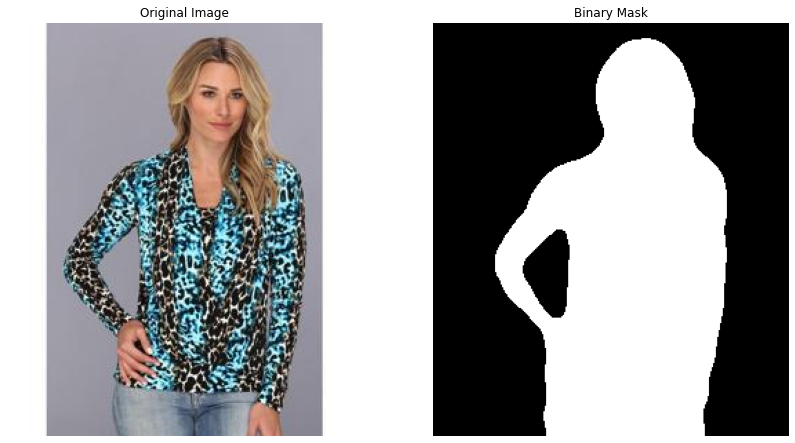

In [ ]:
bin = cv2.bilateralFilter(results.segmentation_mask, 11, 100, 80) #applying a bilateralFilter to smmoothen the edges of the final output

binary_mask = bin > 0.72 # or 0.78

plt.figure(figsize = (14, 10))
plt.subplot(121)
plt.imshow(bg_image[:,:,::-1])
plt.title("Original Image")
plt.axis('off')


plt.subplot(122)
plt.imshow(binary_mask, cmap='gray')
plt.title("Binary Mask")
plt.axis('off')

(-0.5, 257.5, 299.5, -0.5)

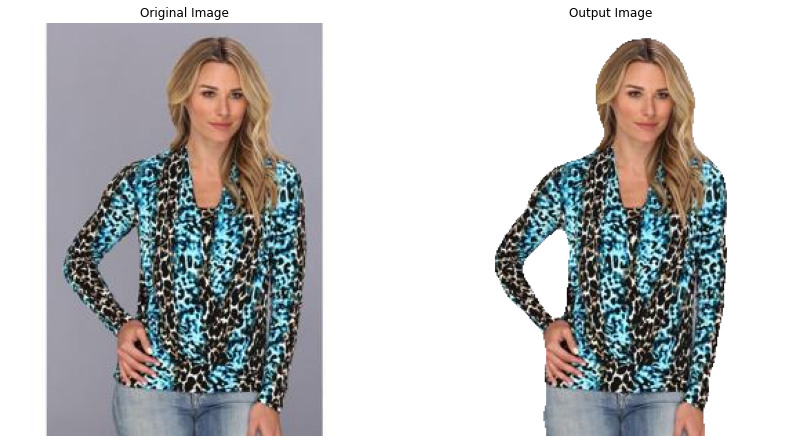

In [ ]:
b_image = cv2.imread("path_to_proposed_background_image")

new_binary_mask = np.dstack((binary_mask,binary_mask,binary_mask))

b_image = cv2.resize(b_image, (new_binary_mask.shape[1], new_binary_mask.shape[0]))

output_image = np.where(new_binary_mask, bg_image, b_image)

plt.figure(figsize=[14,10])

plt.subplot(121)
plt.imshow(bg_image[:,:,::-1])
plt.title("Original Image")
plt.axis('off')


plt.subplot(122)
plt.imshow(output_image[:,:,::-1])
plt.title("Output Image")
plt.axis('off')

### Just trying out with edge detection to smoothen the edges

(-0.5, 257.5, 299.5, -0.5)

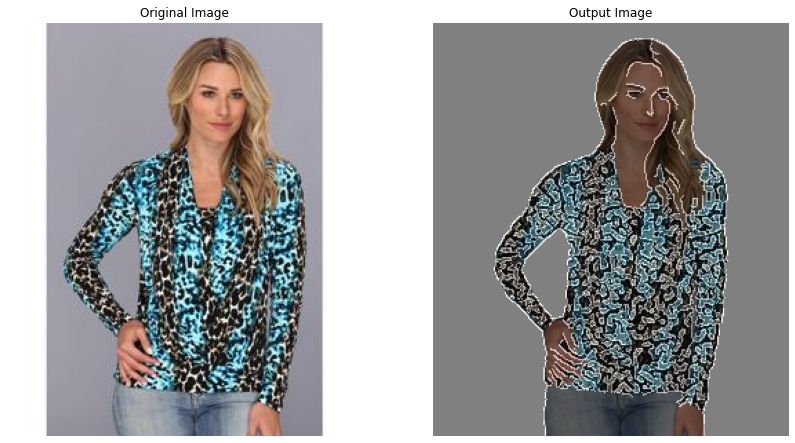

In [ ]:
output_image_copy = output_image.copy()

output_image_copy = cv2.cvtColor(output_image_copy, cv2.COLOR_RGB2GRAY)
output_image_blur = cv2.GaussianBlur(output_image_copy, (5,5), 0)
edges = cv2.Canny(output_image_blur, 225, 100)
edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
# edges_rgb = cv2.resize(edges_rgb, (output_image.shape[1], output_image.shape[0]))

final_output_image = cv2.addWeighted(output_image, 0.5, edges_rgb, 0.5, 0)    

plt.figure(figsize=[14,10])

plt.subplot(121)
plt.imshow(bg_image[:,:,::-1])
plt.title("Original Image")
plt.axis('off')


plt.subplot(122)
plt.imshow(final_output_image[:,:,::-1])
plt.title("Output Image")
plt.axis('off')

### Not much improvement
